In [19]:
#Importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#Filtering Data Analyst roles
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

KeyError: "'veridis' is not a known colormap name"

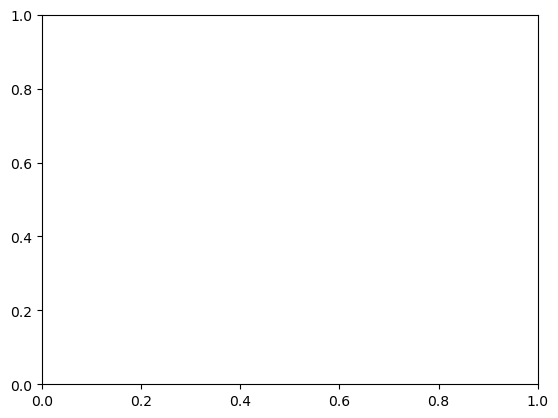

In [ ]:
#create a new column for month no
df_DA['job_posted_month_no'] = df['job_posted_date'].dt.month

#explode the job skills column and pivot
df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index= 'job_posted_month_no',columns='job_skills',aggfunc= 'size',fill_value = 0)

#sort the skills by count
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'] .sort_values(ascending = False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

# use abbreviated month name for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = pd.to_datetime(df_DA_pivot['job_posted_month_no'], format='%m').dt.month_name().str[:3]
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

#get the top 5 skills
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth = 4,
    linestyle = ':',
    colormap='viridis')

plt.title('Top 5 skills for DA per month')
plt.ylabel('Count')
plt.xlabel('Job posted month')
plt.show()
